<a href="https://colab.research.google.com/github/Nskaya7/Anomaly-Detection-for-Financial-Transactions/blob/main/anomaly_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Anomaly Detection for Financial Transactions
Detecting fraudulent transactions using Isolation Forest and Local Outlier Factor on the Credit Card Fraud dataset.

In [1]:
!pip install kaggle -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


## 1. Load Dataset
Using the Credit Card Fraud Detection dataset from Kaggle (284,807 transactions, 492 fraudulent).

In [2]:
df = pd.read_csv('creditcard.csv')
print('Shape:', df.shape)
print('\nClass distribution:')
print(df['Class'].value_counts())
print(f'\nFraud percentage: {df["Class"].mean()*100:.4f}%')

Shape: (156612, 31)

Class distribution:
Class
0.0    156261
1.0       350
Name: count, dtype: int64

Fraud percentage: 0.2235%


## 2. Exploratory Data Analysis

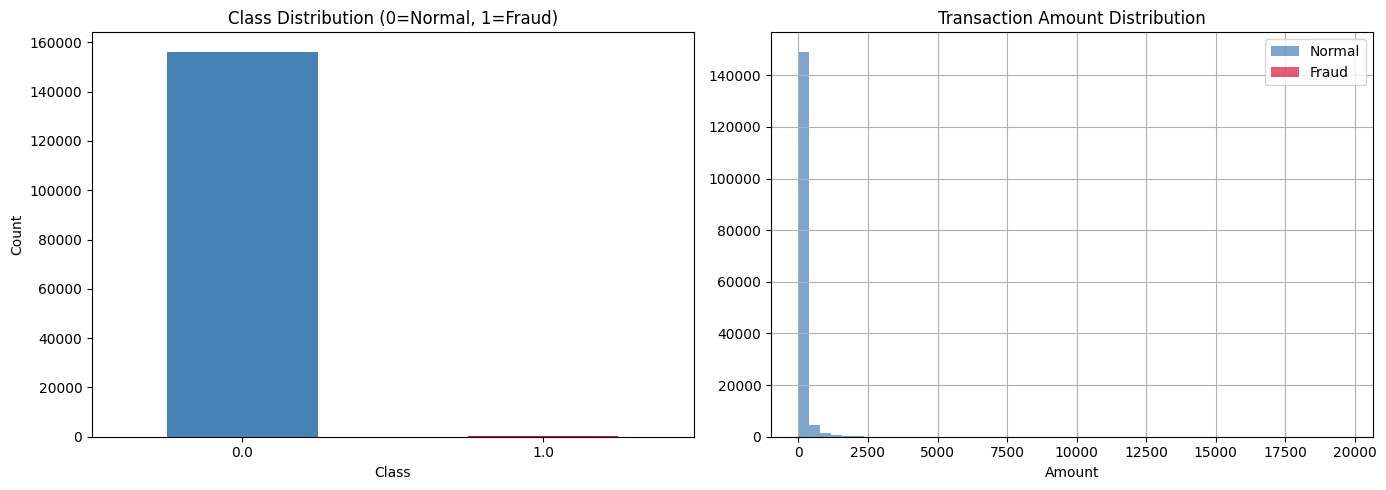

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class imbalance
df['Class'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'crimson'])
axes[0].set_title('Class Distribution (0=Normal, 1=Fraud)')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Transaction amount distribution
df[df['Class']==0]['Amount'].hist(bins=50, ax=axes[1], alpha=0.7, label='Normal', color='steelblue')
df[df['Class']==1]['Amount'].hist(bins=50, ax=axes[1], alpha=0.7, label='Fraud', color='crimson')
axes[1].set_title('Transaction Amount Distribution')
axes[1].set_xlabel('Amount')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda.png', dpi=150)
plt.show()

In [4]:
print(df.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


## 3. Preprocessing

In [5]:
sample = df.dropna(subset=['Class']).copy()
sample['Class'] = sample['Class'].astype(int)
sample = sample.sample(n=10000, random_state=42)

X_sample = sample.drop('Class', axis=1).fillna(0)
y_sample = sample['Class'].values

print('Sample shape:', X_sample.shape)
print('Fraud in sample:', y_sample.sum())

Sample shape: (10000, 30)
Fraud in sample: 22


## 4. Model 1 — Isolation Forest

In [6]:
X_sample = sample.drop('Class', axis=1)
y_sample = sample['Class'].values

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.002,
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_sample)
iso_preds = iso_forest.predict(X_sample)
iso_preds = np.where(iso_preds == -1, 1, 0)

print('=== Isolation Forest ===')
print(classification_report(y_sample, iso_preds, target_names=['Normal', 'Fraud']))
print(f'Precision: {precision_score(y_sample, iso_preds):.4f}')
print(f'Recall:    {recall_score(y_sample, iso_preds):.4f}')
print(f'F1 Score:  {f1_score(y_sample, iso_preds):.4f}')

=== Isolation Forest ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      9978
       Fraud       0.60      0.55      0.57        22

    accuracy                           1.00     10000
   macro avg       0.80      0.77      0.79     10000
weighted avg       1.00      1.00      1.00     10000

Precision: 0.6000
Recall:    0.5455
F1 Score:  0.5714


## 5. Model 2 — Local Outlier Factor

In [8]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.002,
    novelty=False,
    n_jobs=-1
)

lof_preds = lof.fit_predict(X_sample)
lof_preds = np.where(lof_preds == -1, 1, 0)

print('=== Local Outlier Factor ===')
print(classification_report(y_sample, lof_preds, target_names=['Normal', 'Fraud']))
print(f'Precision: {precision_score(y_sample, lof_preds):.4f}')
print(f'Recall:    {recall_score(y_sample, lof_preds):.4f}')
print(f'F1 Score:  {f1_score(y_sample, lof_preds):.4f}')

=== Local Outlier Factor ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      9978
       Fraud       0.00      0.00      0.00        22

    accuracy                           1.00     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       1.00      1.00      1.00     10000

Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000


## 6. Confusion Matrices

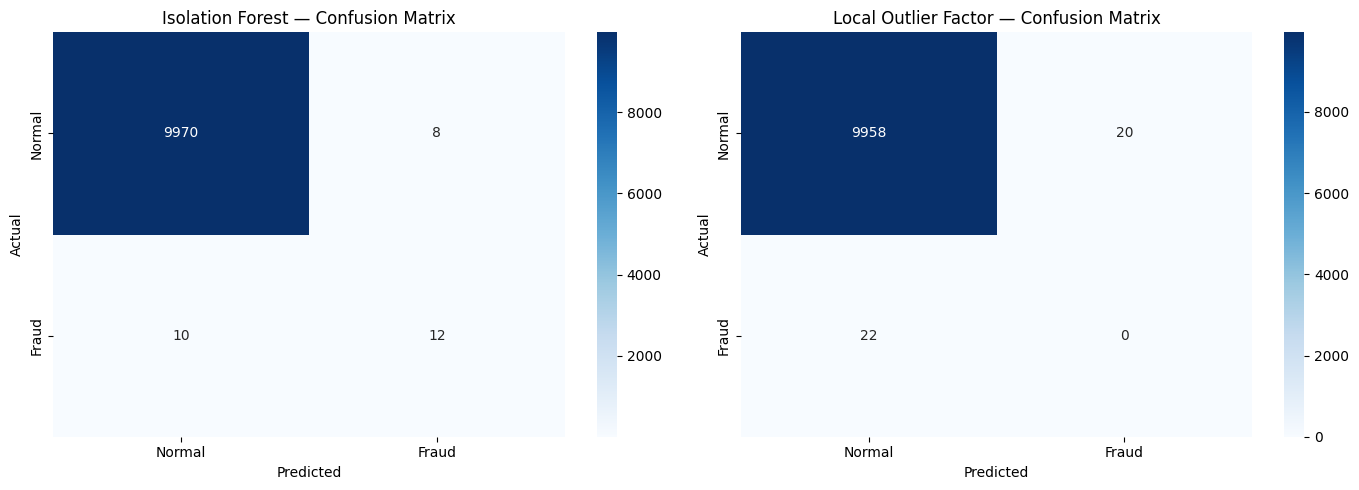

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in zip(
    axes,
    [iso_preds, lof_preds],
    ['Isolation Forest', 'Local Outlier Factor']
):
    cm = confusion_matrix(y_sample, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Fraud'],
                yticklabels=['Normal', 'Fraud'])
    ax.set_title(f'{title} — Confusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

## 7. Anomaly Score Distribution

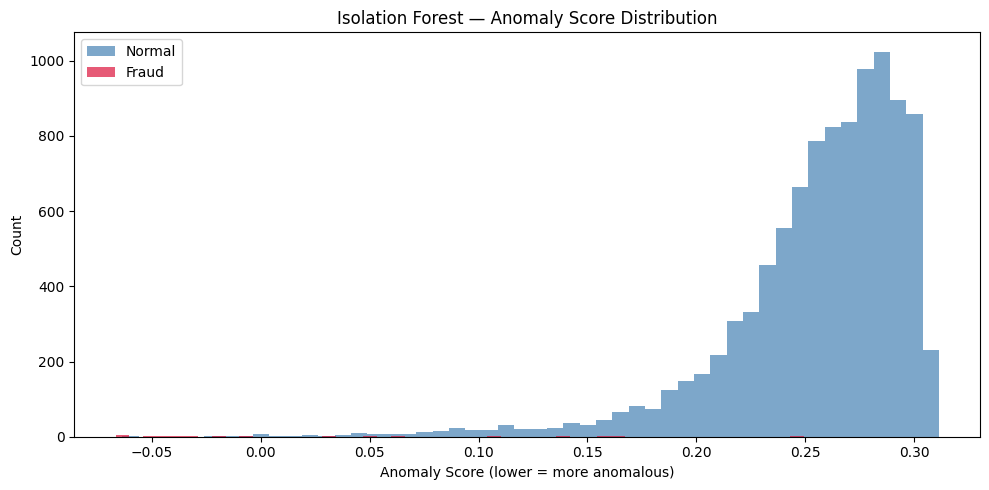

In [11]:
scores = iso_forest.decision_function(X_sample)

plt.figure(figsize=(10, 5))
plt.hist(scores[y_sample==0], bins=50, alpha=0.7, label='Normal', color='steelblue')
plt.hist(scores[y_sample==1], bins=50, alpha=0.7, label='Fraud', color='crimson')
plt.title('Isolation Forest — Anomaly Score Distribution')
plt.xlabel('Anomaly Score (lower = more anomalous)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('anomaly_scores.png', dpi=150)
plt.show()

## 8. Summary
- **Isolation Forest** is faster and scales better to large datasets
- **LOF** is more sensitive to local density variations but memory-intensive
- In fraud detection, **recall matters more than precision**, missing a fraud is more costly than a false alarm
- Both models work without any labeled training data (unsupervised)